In [ ]:
# TP1 — Semana 2
# Baseline de Projeto de Pesquisa
# RSNA Pediatric Bone Age

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Ambiente configurado.")

Ambiente configurado.


In [ ]:
# Download do dataset do Kaggle

!pip install -q kagglehub

import kagglehub

dataset_path = kagglehub.dataset_download("kmader/rsna-bone-age")

print("Dataset baixado!")
print("Localização:", dataset_path)

100%|██████████| 9.29G/9.29G [01:52<00:00, 88.6MB/s]


Extracting files...
Dataset baixado!
Localização: /root/.cache/kagglehub/datasets/kmader/rsna-bone-age/versions/2


In [ ]:
# Baixar o dataset para o Colab

!pip install -q kagglehub

import kagglehub
import os

dataset_path = kagglehub.dataset_download("kmader/rsna-bone-age")

print("Dataset baixado com sucesso!")
print("Caminho:", dataset_path)
print("\nArquivos/pastas encontrados:")

for item in os.listdir(dataset_path):
    print("-", item)

Using Colab cache for faster access to the 'rsna-bone-age' dataset.
Dataset baixado com sucesso!
Caminho: /kaggle/input/rsna-bone-age

Arquivos/pastas encontrados:
- boneage-training-dataset.csv
- boneage-training-dataset
- boneage-test-dataset
- boneage-test-dataset.csv


In [ ]:
# Verificando a estrutura do dataset

print("Conteúdo do dataset:")

for raiz, pastas, arquivos in os.walk(dataset_path):
    nivel = raiz.replace(dataset_path, "").count(os.sep)

    if nivel > 1:
        continue

    print(f"\nPasta: {raiz}")

    for arquivo in arquivos[:10]:
        print(" -", arquivo)

Conteúdo do dataset:

Pasta: /kaggle/input/rsna-bone-age
 - boneage-training-dataset.csv
 - boneage-test-dataset.csv

Pasta: /kaggle/input/rsna-bone-age/boneage-training-dataset

Pasta: /kaggle/input/rsna-bone-age/boneage-test-dataset


In [ ]:
# Carregamento do conjunto de treinamento

BASE_DIR = "/kaggle/input/rsna-bone-age"

TRAIN_CSV = os.path.join(
    BASE_DIR,
    "boneage-training-dataset.csv"
)

TRAIN_IMG_DIR = os.path.join(
    BASE_DIR,
    "boneage-training-dataset"
)

df = pd.read_csv(TRAIN_CSV)

print("Dataset carregado!")
print(f"Quantidade de exames: {len(df)}")
print(f"Colunas: {list(df.columns)}")
print(f"Pasta das imagens: {TRAIN_IMG_DIR}")

Dataset carregado!
Quantidade de exames: 12611
Colunas: ['id', 'boneage', 'male']
Pasta das imagens: /kaggle/input/rsna-bone-age/boneage-training-dataset


In [ ]:
# Correção do caminho das imagens

BASE_DIR = "/kaggle/input/rsna-bone-age"

TRAIN_IMG_DIR = os.path.join(
    BASE_DIR,
    "boneage-training-dataset"
)

print("Pasta das imagens:")
print(TRAIN_IMG_DIR)

Pasta das imagens:
/kaggle/input/rsna-bone-age/boneage-training-dataset


In [ ]:
# Carregamento dos dados

import os
import pandas as pd

BASE_DIR = "/kaggle/input/rsna-bone-age"

TRAIN_CSV = os.path.join(
    BASE_DIR,
    "boneage-training-dataset.csv"
)

TRAIN_IMG_DIR = os.path.join(
    BASE_DIR,
    "boneage-training-dataset"
)

df = pd.read_csv(TRAIN_CSV)

print("Dataset carregado!")
print(f"Quantidade de exames: {len(df)}")
print(f"Colunas: {list(df.columns)}")
print(f"Pasta das imagens: {TRAIN_IMG_DIR}")

Dataset carregado!
Quantidade de exames: 12611
Colunas: ['id', 'boneage', 'male']
Pasta das imagens: /kaggle/input/rsna-bone-age/boneage-training-dataset


In [ ]:
# Verificação de uma imagem

from PIL import Image

amostra = df.iloc[0]

imagem_id = int(amostra["id"])
idade_ossea = amostra["boneage"]
sexo = amostra["male"]

imagem_path = os.path.join(
    TRAIN_IMG_DIR,
    "boneage-training-dataset",
    f"{imagem_id}.png"
)

imagem = Image.open(imagem_path)

print("Imagem:", imagem_id)
print("Idade óssea:", idade_ossea, "meses")
print("Sexo masculino:", sexo)
print("Formato:", imagem.format)
print("Tamanho:", imagem.size)
print("Modo:", imagem.mode)

Imagem: 1377
Idade óssea: 180 meses
Sexo masculino: False
Formato: PNG
Tamanho: (1514, 2044)
Modo: L


In [ ]:
# Procurando a imagem pelo ID

imagem_id = int(df.iloc[0]["id"])

for raiz, pastas, arquivos in os.walk(BASE_DIR):
    nome_imagem = f"{imagem_id}.png"

    if nome_imagem in arquivos:
        print("Imagem encontrada!")
        print(os.path.join(raiz, nome_imagem))
        break
else:
    print("Imagem não encontrada.")

Imagem encontrada!
/kaggle/input/rsna-bone-age/boneage-training-dataset/boneage-training-dataset/1377.png


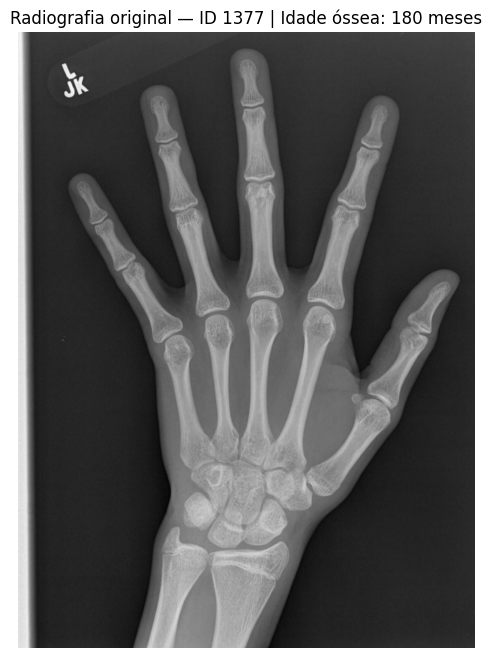

In [ ]:
# Visualização da imagem original

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 8))

plt.imshow(imagem, cmap="gray")
plt.title(
    f"Radiografia original — ID {imagem_id} | "
    f"Idade óssea: {idade_ossea} meses"
)
plt.axis("off")

plt.show()

In [ ]:
# Pré-processamento da imagem

import numpy as np

# Conversão para escala de cinza e array NumPy
imagem_array = np.array(imagem.convert("L"))

# Redimensionamento para tamanho fixo
TAMANHO = (256, 256)

imagem_redimensionada = imagem.resize(TAMANHO)

# Conversão para array
imagem_processada = np.array(imagem_redimensionada)

# Normalização dos pixels para o intervalo [0, 1]
imagem_normalizada = imagem_processada.astype(np.float32) / 255.0

print("Pré-processamento concluído!")
print("Tamanho original:", imagem.size)
print("Tamanho após redimensionamento:", imagem_redimensionada.size)
print("Valor mínimo após normalização:", imagem_normalizada.min())
print("Valor máximo após normalização:", imagem_normalizada.max())

Pré-processamento concluído!
Tamanho original: (1514, 2044)
Tamanho após redimensionamento: (256, 256)
Valor mínimo após normalização: 0.023529412
Valor máximo após normalização: 1.0


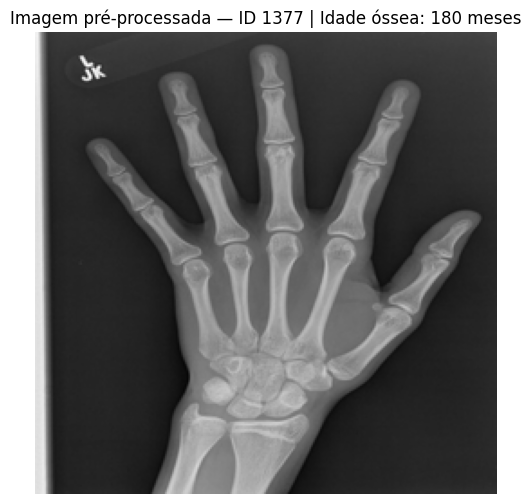

In [ ]:
# Visualização da imagem após o pré-processamento

plt.figure(figsize=(6, 6))

plt.imshow(imagem_normalizada, cmap="gray", vmin=0, vmax=1)

plt.title(
    f"Imagem pré-processada — ID {imagem_id} | "
    f"Idade óssea: {idade_ossea} meses"
)

plt.axis("off")
plt.show()


In [ ]:
# Divisão dos dados em treino e validação

from sklearn.model_selection import train_test_split

SEED = 42

df_treino, df_validacao = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED
)

print("Divisão dos dados concluída!")
print(f"Exames para treino: {len(df_treino)}")
print(f"Exames para validação: {len(df_validacao)}")
print(f"Percentual de validação: {len(df_validacao) / len(df) * 100:.1f}%")

Divisão dos dados concluída!
Exames para treino: 10088
Exames para validação: 2523
Percentual de validação: 20.0%


In [ ]:
# Baseline trivial — média da idade óssea

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calcula a média da idade óssea apenas no conjunto de treino
idade_media_treino = df_treino["boneage"].mean()

# O baseline prevê essa mesma média para todos os exames de validação
previsoes_baseline = np.full(
    len(df_validacao),
    idade_media_treino
)

# Valores reais
idades_reais = df_validacao["boneage"].values

# Métricas
mae_baseline = mean_absolute_error(
    idades_reais,
    previsoes_baseline
)

rmse_baseline = np.sqrt(
    mean_squared_error(
        idades_reais,
        previsoes_baseline
    )
)

r2_baseline = r2_score(
    idades_reais,
    previsoes_baseline
)

print("=== Baseline Trivial ===")
print(f"Média da idade óssea no treino: {idade_media_treino:.2f} meses")
print(f"MAE: {mae_baseline:.2f} meses")
print(f"RMSE: {rmse_baseline:.2f} meses")
print(f"R²: {r2_baseline:.4f}")

=== Baseline Trivial ===
Média da idade óssea no treino: 127.20 meses
MAE: 34.51 meses
RMSE: 42.09 meses
R²: -0.0002


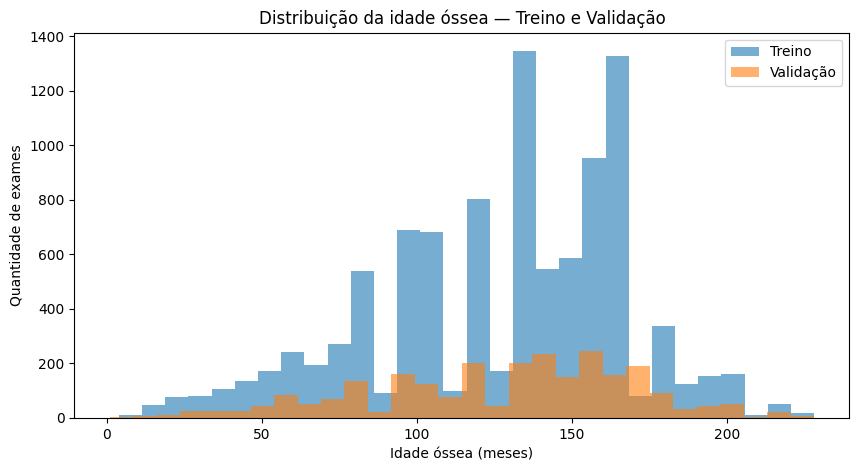

In [ ]:
# Comparação das idades nos conjuntos de treino e validação

plt.figure(figsize=(10, 5))

plt.hist(
    df_treino["boneage"],
    bins=30,
    alpha=0.6,
    label="Treino"
)

plt.hist(
    df_validacao["boneage"],
    bins=30,
    alpha=0.6,
    label="Validação"
)

plt.xlabel("Idade óssea (meses)")
plt.ylabel("Quantidade de exames")
plt.title("Distribuição da idade óssea — Treino e Validação")
plt.legend()

plt.show()

In [ ]:
# Congelamento da partição treino/validação

# Criar uma cópia do dataset original
df_particao = df.copy()

# Marcar cada exame com seu conjunto
df_particao["conjunto"] = "treino"

df_particao.loc[
    df_particao["id"].isin(df_validacao["id"]),
    "conjunto"
] = "validacao"

# Conferir a divisão
print("=== Partição congelada ===")
print(df_particao["conjunto"].value_counts())

# Salvar a partição para reutilização
CAMINHO_PARTICAO = "/content/particao_rsna_bone_age.csv"

df_particao.to_csv(
    CAMINHO_PARTICAO,
    index=False
)

print("\nPartição salva em:")
print(CAMINHO_PARTICAO)

=== Partição congelada ===
conjunto
treino       10088
validacao     2523
Name: count, dtype: int64

Partição salva em:
/content/particao_rsna_bone_age.csv


In [ ]:
# Importação do HOG

from skimage.feature import hog

print("HOG importado com sucesso!")

HOG importado com sucesso!


In [ ]:
# Extração do descritor HOG em uma imagem

caracteristicas_hog = hog(
    imagem_normalizada,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys"
)

print("HOG extraído com sucesso!")
print("Quantidade de características:", len(caracteristicas_hog))
print("Primeiras características:")
print(caracteristicas_hog[:10])

HOG extraído com sucesso!
Quantidade de características: 34596
Primeiras características:
[0.4989878  0.         0.         0.         0.00579596 0.
 0.         0.         0.4989878  0.02401184]


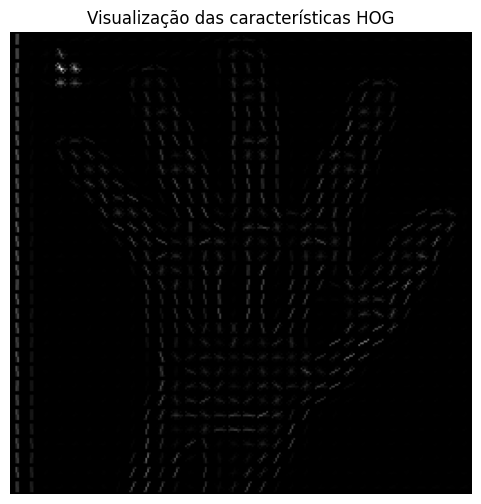

Quantidade de características: 34596


In [ ]:
# Visualização das características HOG

caracteristicas_hog, imagem_hog = hog(
    imagem_normalizada,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True
)

plt.figure(figsize=(6, 6))

plt.imshow(imagem_hog, cmap="gray")

plt.title("Visualização das características HOG")

plt.axis("off")
plt.show()

print("Quantidade de características:", len(caracteristicas_hog))

In [ ]:
# Função para pré-processamento + extração HOG

from PIL import Image
import numpy as np
from skimage.feature import hog
import os

TAMANHO = (256, 256)

def extrair_hog(imagem_id):
    # Caminho da imagem
    caminho_imagem = os.path.join(
        TRAIN_IMG_DIR,
        "boneage-training-dataset",
        f"{int(imagem_id)}.png"
    )

    # Abrir imagem
    imagem = Image.open(caminho_imagem).convert("L")

    # Redimensionar
    imagem = imagem.resize(TAMANHO)

    # Converter para números
    imagem_array = np.array(imagem)

    # Normalizar pixels para 0–1
    imagem_normalizada = imagem_array.astype(np.float32) / 255.0

    # Extrair características HOG
    caracteristicas = hog(
        imagem_normalizada,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    return caracteristicas


print("Função criada com sucesso!")

Função criada com sucesso!


In [ ]:
# Teste da função em 3 exames

ids_teste = df_treino["id"].head(3).tolist()

for imagem_id_teste in ids_teste:
    caracteristicas = extrair_hog(imagem_id_teste)

    print(
        f"ID {imagem_id_teste} → "
        f"{len(caracteristicas)} características"
    )

ID 13908 → 34596 características
ID 14699 → 34596 características
ID 11430 → 34596 características


In [ ]:
# Teste de extração HOG em lote

import time
import numpy as np

# Selecionar 20 exames do conjunto de treino
ids_lote = df_treino["id"].head(20).tolist()

inicio = time.time()

caracteristicas_lote = []

for imagem_id_teste in ids_lote:
    caracteristicas = extrair_hog(imagem_id_teste)
    caracteristicas_lote.append(caracteristicas)

# Transformar a lista em uma matriz NumPy
X_lote = np.array(caracteristicas_lote, dtype=np.float32)

tempo = time.time() - inicio

print("=== Teste de processamento em lote ===")
print("Quantidade de imagens:", len(ids_lote))
print("Formato da matriz:", X_lote.shape)
print(f"Tempo de processamento: {tempo:.2f} segundos")
print(f"Tempo médio por imagem: {tempo / len(ids_lote):.2f} segundos")

=== Teste de processamento em lote ===
Quantidade de imagens: 20
Formato da matriz: (20, 34596)
Tempo de processamento: 1.91 segundos
Tempo médio por imagem: 0.10 segundos


In [ ]:
# Teste de HOG mais compacto

caracteristicas_hog_compacto = hog(
    imagem_normalizada,
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    block_norm="L2-Hys"
)

print("HOG compacto extraído!")
print(
    "Quantidade de características:",
    len(caracteristicas_hog_compacto)
)
print("Primeiras características:")
print(caracteristicas_hog_compacto[:10])

HOG compacto extraído!
Quantidade de características: 8100
Primeiras características:
[0.31767657 0.00045535 0.0020159  0.00227673 0.00875637 0.00401998
 0.00850983 0.0093168  0.31767657 0.04333793]


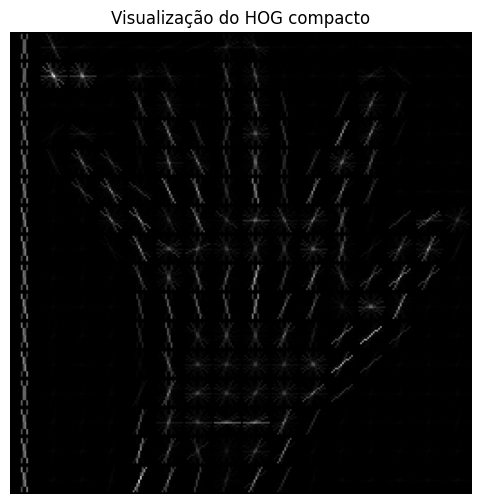

Quantidade de características: 8100


In [ ]:
# Visualização do HOG compacto

caracteristicas_hog_compacto, imagem_hog_compacto = hog(
    imagem_normalizada,
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True
)

plt.figure(figsize=(6, 6))
plt.imshow(imagem_hog_compacto, cmap="gray")
plt.title("Visualização do HOG compacto")
plt.axis("off")
plt.show()

print("Quantidade de características:", len(caracteristicas_hog_compacto))

In [ ]:
import time
import numpy as np

# Vamos testar o HOG compacto em 20 imagens
ids_lote = df_treino["id"].head(20).tolist()

inicio = time.time()

caracteristicas_lote_compacto = []

for imagem_id_teste in ids_lote:
    caminho_imagem = os.path.join(
        TRAIN_IMG_DIR,
        "boneage-training-dataset",
        f"{int(imagem_id_teste)}.png"
    )

    imagem = Image.open(caminho_imagem).convert("L")
    imagem = imagem.resize(TAMANHO)

    imagem_array = np.array(imagem)
    imagem_normalizada = imagem_array.astype(np.float32) / 255.0

    caracteristicas = hog(
        imagem_normalizada,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    caracteristicas_lote_compacto.append(caracteristicas)

X_lote_compacto = np.array(
    caracteristicas_lote_compacto,
    dtype=np.float32
)

tempo = time.time() - inicio

print("=== Teste do HOG compacto em lote ===")
print("Quantidade de imagens:", len(ids_lote))
print("Formato da matriz:", X_lote_compacto.shape)
print(f"Tempo de processamento: {tempo:.2f} segundos")
print(f"Tempo médio por imagem: {tempo / len(ids_lote):.2f} segundos")

=== Teste do HOG compacto em lote ===
Quantidade de imagens: 20
Formato da matriz: (20, 8100)
Tempo de processamento: 1.31 segundos
Tempo médio por imagem: 0.07 segundos


In [ ]:
# Amostra reproduzível para o primeiro modelo

SEED = 42

df_treino_amostra = df_treino.sample(
    n=3000,
    random_state=SEED
).copy()

df_validacao_amostra = df_validacao.sample(
    n=750,
    random_state=SEED
).copy()

print("=== Amostra definida ===")
print("Treino:", len(df_treino_amostra))
print("Validação:", len(df_validacao_amostra))

print("\nProporção de validação:")
print(
    len(df_validacao_amostra) /
    (len(df_treino_amostra) + len(df_validacao_amostra))
)

=== Amostra definida ===
Treino: 3000
Validação: 750

Proporção de validação:
0.2


In [ ]:
# Função para extrair HOG compacto de uma imagem

def extrair_hog_compacto(imagem_id):
    caminho_imagem = os.path.join(
        TRAIN_IMG_DIR,
        "boneage-training-dataset",
        f"{int(imagem_id)}.png"
    )

    imagem = Image.open(caminho_imagem).convert("L")
    imagem = imagem.resize(TAMANHO)

    imagem_array = np.array(imagem)
    imagem_normalizada = imagem_array.astype(np.float32) / 255.0

    caracteristicas = hog(
        imagem_normalizada,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )

    return caracteristicas.astype(np.float32)


print("Função HOG compacto criada com sucesso!")

Função HOG compacto criada com sucesso!


In [ ]:
# Teste da função HOG compacto

imagem_id_teste = df_treino_amostra.iloc[0]["id"]

caracteristicas_teste = extrair_hog_compacto(imagem_id_teste)

print("=== Teste da função ===")
print("ID da imagem:", int(imagem_id_teste))
print("Quantidade de características:", len(caracteristicas_teste))
print("Tipo dos dados:", caracteristicas_teste.dtype)


=== Teste da função ===
ID da imagem: 6542
Quantidade de características: 8100
Tipo dos dados: float32


In [ ]:
from tqdm.auto import tqdm
import time

inicio = time.time()

caracteristicas_treino = []

for imagem_id in tqdm(
    df_treino_amostra["id"],
    desc="Extraindo HOG do treino"
):
    caracteristicas = extrair_hog_compacto(imagem_id)
    caracteristicas_treino.append(caracteristicas)

X_treino_hog = np.array(
    caracteristicas_treino,
    dtype=np.float32
)

tempo_total = time.time() - inicio

print("\n=== HOG do conjunto de treino ===")
print("Quantidade de imagens:", len(X_treino_hog))
print("Formato da matriz:", X_treino_hog.shape)
print(f"Tempo total: {tempo_total / 60:.2f} minutos")
print(f"Tempo médio por imagem: {tempo_total / len(X_treino_hog):.2f} segundos")

Extraindo HOG do treino:   0%|          | 0/3000 [00:00<?, ?it/s]


=== HOG do conjunto de treino ===
Quantidade de imagens: 3000
Formato da matriz: (3000, 8100)
Tempo total: 3.79 minutos
Tempo médio por imagem: 0.08 segundos


In [ ]:
# Salvando as características HOG do treino

CAMINHO_X_TREINO = "/content/X_treino_hog.npy"

np.save(
    CAMINHO_X_TREINO,
    X_treino_hog
)

print("Características HOG do treino salvas!")
print("Caminho:", CAMINHO_X_TREINO)
print("Formato salvo:", X_treino_hog.shape)

Características HOG do treino salvas!
Caminho: /content/X_treino_hog.npy
Formato salvo: (3000, 8100)


In [ ]:
# Extraindo HOG compacto das imagens de validação

inicio = time.time()

caracteristicas_validacao = []

for imagem_id in tqdm(
    df_validacao_amostra["id"],
    desc="Extraindo HOG da validação"
):
    caracteristicas = extrair_hog_compacto(imagem_id)
    caracteristicas_validacao.append(caracteristicas)

X_validacao_hog = np.array(
    caracteristicas_validacao,
    dtype=np.float32
)

tempo_total = time.time() - inicio

print("\n=== HOG do conjunto de validação ===")
print("Quantidade de imagens:", len(X_validacao_hog))
print("Formato da matriz:", X_validacao_hog.shape)
print(f"Tempo total: {tempo_total / 60:.2f} minutos")
print(f"Tempo médio por imagem: {tempo_total / len(X_validacao_hog):.2f} segundos")

Extraindo HOG da validação:   0%|          | 0/750 [00:00<?, ?it/s]


=== HOG do conjunto de validação ===
Quantidade de imagens: 750
Formato da matriz: (750, 8100)
Tempo total: 0.93 minutos
Tempo médio por imagem: 0.07 segundos


In [ ]:
# Salvando as características HOG da validação

CAMINHO_X_VALIDACAO = "/content/X_validacao_hog.npy"

np.save(
    CAMINHO_X_VALIDACAO,
    X_validacao_hog
)

print("Características HOG da validação salvas!")
print("Caminho:", CAMINHO_X_VALIDACAO)
print("Formato salvo:", X_validacao_hog.shape)

Características HOG da validação salvas!
Caminho: /content/X_validacao_hog.npy
Formato salvo: (750, 8100)


In [ ]:
# Preparando os valores reais de idade óssea

y_treino = df_treino_amostra["boneage"].values.astype(np.float32)
y_validacao = df_validacao_amostra["boneage"].values.astype(np.float32)

print("=== Valores de idade óssea ===")
print("Treino:")
print("  Quantidade:", len(y_treino))
print("  Formato:", y_treino.shape)

print("\nValidação:")
print("  Quantidade:", len(y_validacao))
print("  Formato:", y_validacao.shape)

print("\nConferência:")
print("  X_treino:", X_treino_hog.shape)
print("  y_treino:", y_treino.shape)
print("  X_validação:", X_validacao_hog.shape)
print("  y_validação:", y_validacao.shape)

=== Valores de idade óssea ===
Treino:
  Quantidade: 3000
  Formato: (3000,)

Validação:
  Quantidade: 750
  Formato: (750,)

Conferência:
  X_treino: (3000, 8100)
  y_treino: (3000,)
  X_validação: (750, 8100)
  y_validação: (750,)


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Criando o modelo Ridge
modelo_ridge = Ridge(alpha=10.0)

# Treinando
modelo_ridge.fit(X_treino_hog, y_treino)

# Fazendo previsões na validação
previsoes_ridge = modelo_ridge.predict(X_validacao_hog)

# Calculando as métricas
mae_ridge = mean_absolute_error(y_validacao, previsoes_ridge)
rmse_ridge = np.sqrt(
    mean_squared_error(y_validacao, previsoes_ridge)
)
r2_ridge = r2_score(y_validacao, previsoes_ridge)

print("=== Primeiro modelo: Ridge Regression ===")
print(f"MAE:  {mae_ridge:.2f} meses")
print(f"RMSE: {rmse_ridge:.2f} meses")
print(f"R²:   {r2_ridge:.4f}")

=== Primeiro modelo: Ridge Regression ===
MAE:  22.48 meses
RMSE: 29.91 meses
R²:   0.4699


In [ ]:
# Tabela inicial de resultados

resultados = pd.DataFrame({
    "Modelo": [
        "Baseline - Média",
        "Ridge + HOG"
    ],
    "MAE (meses)": [
        mae_baseline,
        mae_ridge
    ],
    "RMSE (meses)": [
        rmse_baseline,
        rmse_ridge
    ],
    "R²": [
        r2_baseline,
        r2_ridge
    ]
})

resultados

,Modelo,MAE (meses),RMSE (meses),R²
0,Baseline - Média,34.513076,42.090381,-0.000198
1,Ridge + HOG,22.479572,29.907247,0.469917


In [ ]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

print("Modelo Random Forest criado!")

Modelo Random Forest criado!


In [ ]:
# Treinando o Random Forest

inicio = time.time()

modelo_rf.fit(X_treino_hog, y_treino)

tempo_treino_rf = time.time() - inicio

print("=== Treinamento do Random Forest ===")
print("Treinamento concluído!")
print(f"Tempo de treinamento: {tempo_treino_rf / 60:.2f} minutos")

=== Treinamento do Random Forest ===
Treinamento concluído!
Tempo de treinamento: 33.05 minutos


In [ ]:
# Fazendo previsões com o Random Forest

inicio = time.time()

previsoes_rf = modelo_rf.predict(X_validacao_hog)

tempo_predicao_rf = time.time() - inicio

print("=== Previsões do Random Forest ===")
print("Previsões concluídas!")
print("Quantidade de previsões:", len(previsoes_rf))
print(f"Tempo de predição: {tempo_predicao_rf:.2f} segundos")

=== Previsões do Random Forest ===
Previsões concluídas!
Quantidade de previsões: 750
Tempo de predição: 0.18 segundos


In [ ]:
# Avaliando o Random Forest

mae_rf = mean_absolute_error(y_validacao, previsoes_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_validacao, previsoes_rf)
)

r2_rf = r2_score(
    y_validacao,
    previsoes_rf
)

print("=== Segundo modelo: Random Forest ===")
print(f"MAE:  {mae_rf:.2f} meses")
print(f"RMSE: {rmse_rf:.2f} meses")
print(f"R²:   {r2_rf:.4f}")

=== Segundo modelo: Random Forest ===
MAE:  27.85 meses
RMSE: 34.35 meses
R²:   0.3007


In [ ]:
# Adicionando o Random Forest à tabela de resultados

resultados.loc[len(resultados)] = [
    "Random Forest + HOG",
    mae_rf,
    rmse_rf,
    r2_rf
]

resultados

,Modelo,MAE (meses),RMSE (meses),R²
0,Baseline - Média,34.513076,42.090381,-0.000198
1,Ridge + HOG,22.479572,29.907247,0.469917
2,Random Forest + HOG,27.851157,34.349646,0.300745


In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

modelo_sgd = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", SGDRegressor(
        loss="squared_error",
        penalty="l2",
        alpha=0.0001,
        max_iter=1000,
        random_state=42
    ))
])

print("Terceiro modelo criado!")

Terceiro modelo criado!


In [ ]:
# Treinando o SGDRegressor

inicio = time.time()

modelo_sgd.fit(X_treino_hog, y_treino)

tempo_treino_sgd = time.time() - inicio

print("=== Treinamento do SGDRegressor ===")
print("Treinamento concluído!")
print(f"Tempo de treinamento: {tempo_treino_sgd / 60:.2f} minutos")

=== Treinamento do SGDRegressor ===
Treinamento concluído!
Tempo de treinamento: 0.22 minutos


In [ ]:
# Fazendo previsões com o SGDRegressor

inicio = time.time()

previsoes_sgd = modelo_sgd.predict(X_validacao_hog)

tempo_predicao_sgd = time.time() - inicio

# Calculando as métricas
mae_sgd = mean_absolute_error(y_validacao, previsoes_sgd)

rmse_sgd = np.sqrt(
    mean_squared_error(y_validacao, previsoes_sgd)
)

r2_sgd = r2_score(
    y_validacao,
    previsoes_sgd
)

print("=== Terceiro modelo: SGDRegressor ===")
print("Previsões concluídas!")
print(f"Quantidade de previsões: {len(previsoes_sgd)}")
print(f"Tempo de predição: {tempo_predicao_sgd:.2f} segundos")
print(f"MAE:  {mae_sgd:.2f} meses")
print(f"RMSE: {rmse_sgd:.2f} meses")
print(f"R²:   {r2_sgd:.4f}")

=== Terceiro modelo: SGDRegressor ===
Previsões concluídas!
Quantidade de previsões: 750
Tempo de predição: 0.09 segundos
MAE:  1169163098655.14 meses
RMSE: 1484924141617.94 meses
R²:   -1306771635309821820928.0000


In [ ]:
# Verificando as previsões do SGDRegressor

print("=== Verificação das previsões ===")
print("Mínimo:", np.min(previsoes_sgd))
print("Máximo:", np.max(previsoes_sgd))
print("Média:", np.mean(previsoes_sgd))
print("Primeiras 10 previsões:")
print(previsoes_sgd[:10])

print("\nIdades reais:")
print("Mínimo:", np.min(y_validacao))
print("Máximo:", np.max(y_validacao))
print("Média:", np.mean(y_validacao))

=== Verificação das previsões ===
Mínimo: -5327794877701.969
Máximo: 4319098555130.031
Média: 29255323847.51369
Primeiras 10 previsões:
[-5.20489678e+11 -8.33662367e+11  1.33561044e+11 -9.45422612e+11
 -7.53902302e+11 -1.60994087e+12 -1.59986760e+12 -3.72455913e+11
 -6.89707038e+11 -1.75401089e+12]

Idades reais:
Mínimo: 6.0
Máximo: 228.0
Média: 130.424


In [ ]:
from sklearn.tree import DecisionTreeRegressor

modelo_arvore = DecisionTreeRegressor(
    max_depth=12,
    max_features="sqrt",
    random_state=SEED
)

print("Treinando Árvore de Decisão...")

modelo_arvore.fit(X_treino_hog, y_treino)

print("Treinamento concluído!")

Treinando Árvore de Decisão...
Treinamento concluído!


In [ ]:
print("Fazendo previsões...")

previsoes_arvore = modelo_arvore.predict(X_validacao_hog)

print("Previsões concluídas!")
print("Quantidade de previsões:", len(previsoes_arvore))
print("Primeiras 10 previsões:")
print(previsoes_arvore[:10])

Fazendo previsões...
Previsões concluídas!
Quantidade de previsões: 750
Primeiras 10 previsões:
[ 50.66666667  90.5        135.          75.         156.
 100.         106.85714286 154.51764706  95.         120.        ]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_arvore = mean_absolute_error(y_validacao, previsoes_arvore)
rmse_arvore = np.sqrt(mean_squared_error(y_validacao, previsoes_arvore))
r2_arvore = r2_score(y_validacao, previsoes_arvore)

print("=== Árvore de Decisão + HOG ===")
print(f"MAE: {mae_arvore:.2f} meses")
print(f"RMSE: {rmse_arvore:.2f} meses")
print(f"R²: {r2_arvore:.4f}")

=== Árvore de Decisão + HOG ===
MAE: 37.93 meses
RMSE: 49.44 meses
R²: -0.4485
